# Tiền xử lý dữ liệu văn bản - Traffic Law Chatbot

Notebook này thực hiện **7 bước tiền xử lý** văn bản tiếng Việt cho dữ liệu luật giao thông đường bộ, phục vụ xây dựng Retrieval Chatbot AI.

**Dữ liệu đầu vào:**
- `luat_duong_bo_35-2024.json` — Luật Trật tự, An toàn giao thông đường bộ 35/2024/QH15
- `nd168_xu_phat_2024.json` — Nghị định 168/2024/NĐ-CP về xử phạt vi phạm giao thông

**7 bước tiền xử lý:**
1. Chuyển về chữ thường (Lowercasing)
2. Xóa dấu chấm câu (Removing Punctuation)
3. Xóa từ dừng (Removing Stop Words)
4. Chuẩn hóa văn bản (Text Standardization)
5. Chỉnh sửa chính tả (Spelling Correction)
6. Tách từ (Tokenization)
7. Khám phá dữ liệu (Exploring Text Data)

## 0. Cài đặt và Import thư viện

In [21]:
# Cài đặt thư viện
import sys
!{sys.executable} -m pip install -q underthesea wordcloud matplotlib

'c:\Program' is not recognized as an internal or external command,
operable program or batch file.


In [22]:
# Import thư viện
import json
import re
import string
import unicodedata
from pathlib import Path
from collections import Counter
from datetime import datetime

import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [23]:
# Đọc dữ liệu từ các file JSON đã crawl
BASE_DIR = Path(r"C:\Users\ASUS-PRO\Desktop\Traffic_Law_Chatbot")
RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

# Đọc Luật 35/2024
with open(RAW_DIR / "luat_duong_bo_35-2024.json", encoding="utf-8") as f:
    luat_35 = json.load(f)

# Đọc Nghị định 168/2024
with open(RAW_DIR / "nd168_xu_phat_2024.json", encoding="utf-8") as f:
    nd168 = json.load(f)

# Gộp toàn bộ văn bản
documents = [
    {"name": "Luật 35/2024/QH15", "text": luat_35["full_text"]},
    {"name": "Nghị định 168/2024/NĐ-CP", "text": nd168["full_text"]},
]

# Tạo danh sách các đoạn văn bản (theo trang) để xử lý
all_pages = []
for page in luat_35.get("pages", []):
    all_pages.append({"source": "Luật 35/2024", "page": page["page_number"], "text": page["content"]})
for page in nd168.get("pages", []):
    all_pages.append({"source": "NĐ 168/2024", "page": page["page_number"], "text": page["content"]})

print(f"✓ Đã đọc {len(documents)} văn bản pháp luật")
print(f"✓ Tổng số trang: {len(all_pages)}")
for doc in documents:
    print(f"  - {doc['name']}: {len(doc['text']):,} ký tự")

✓ Đã đọc 2 văn bản pháp luật
✓ Tổng số trang: 157
  - Luật 35/2024/QH15: 149,931 ký tự
  - Nghị định 168/2024/NĐ-CP: 255,063 ký tự


## Bước 1: Chuyển về chữ thường (Lowercasing)

**Vấn đề:** Văn bản pháp luật chứa nhiều chữ in hoa (tiêu đề chương, điều, tên riêng).

**Xử lý:** Sử dụng hàm `lower()` để chuyển toàn bộ văn bản về chữ thường.

**Mục đích:** Đồng nhất dữ liệu, giúp so khớp từ chính xác hơn khi retrieval.

In [24]:
# Bước 1: Lowercasing - Chuyển về chữ thường
print("=" * 50)
print("BƯỚC 1: CHUYỂN VỀ CHỮ THƯỜNG (LOWERCASING)")
print("=" * 50)

def lowercase_text(text):
    """Chuyển toàn bộ văn bản về chữ thường"""
    return text.lower()

# Áp dụng cho tất cả các trang
for page in all_pages:
    page["text_processed"] = lowercase_text(page["text"])

# Demo kết quả
sample = all_pages[0]
print(f"\n📌 Nguồn: {sample['source']} - Trang {sample['page']}")
print(f"\n🔹 TRƯỚC (original):")
print(sample["text"][:300])
print(f"\n🔹 SAU (lowercased):")
print(sample["text_processed"][:300])
print(f"\n✓ Đã chuyển {len(all_pages)} trang về chữ thường")

BƯỚC 1: CHUYỂN VỀ CHỮ THƯỜNG (LOWERCASING)

📌 Nguồn: Luật 35/2024 - Trang 1

🔹 TRƯỚC (original):
CÔNG BÁO/Số 983 + 984/Ngày 25-8-2024 3
QUỐC HỘI CỘNG HÒA XÃ HỘI CHỦ NGHĨA VIỆT NAM
Độc lập - Tự do - Hạnh phúc
Luật số: 35/2024/QH15
LUẬT
ĐƯỜNG BỘ
Căn cứ Hiến pháp nước Cộng hòa xã hội chủ nghĩa Việt Nam;
Quốc hội ban hành Luật Đường bộ.
Chương I
NHỮNG QUY ĐỊNH CHUNG
Điều 1. Phạm vi điều chỉnh
Luật 

🔹 SAU (lowercased):
công báo/số 983 + 984/ngày 25-8-2024 3
quốc hội cộng hòa xã hội chủ nghĩa việt nam
độc lập - tự do - hạnh phúc
luật số: 35/2024/qh15
luật
đường bộ
căn cứ hiến pháp nước cộng hòa xã hội chủ nghĩa việt nam;
quốc hội ban hành luật đường bộ.
chương i
những quy định chung
điều 1. phạm vi điều chỉnh
luật 

✓ Đã chuyển 157 trang về chữ thường


## Bước 2: Xóa dấu chấm câu (Remove Punctuation)
Loại bỏ các ký tự đặc biệt, dấu chấm câu nhưng **giữ lại dấu tiếng Việt** (dấu thanh, dấu mũ).

In [25]:
# Bước 2: Xóa dấu chấm câu (Remove Punctuation)
print("=" * 50)
print("BƯỚC 2: XÓA DẤU CHẤM CÂU (REMOVE PUNCTUATION)")
print("=" * 50)

def remove_punctuation(text):
    """
    Xóa dấu chấm câu và ký tự đặc biệt.
    Giữ lại: chữ cái (kể cả tiếng Việt có dấu), chữ số, khoảng trắng.
    """
    # Giữ lại ký tự chữ (Unicode), số, khoảng trắng
    cleaned = re.sub(r'[^\w\s]', ' ', text)
    # Xóa khoảng trắng thừa
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned

# Áp dụng
for page in all_pages:
    page["text_processed"] = remove_punctuation(page["text_processed"])

# Demo kết quả
sample = all_pages[0]
print(f"\n📌 Nguồn: {sample['source']} - Trang {sample['page']}")
print(f"\n🔹 TRƯỚC (lowercased):")
print(lowercase_text(sample["text"])[:300])
print(f"\n🔹 SAU (removed punctuation):")
print(sample["text_processed"][:300])

# Thống kê
total_chars_before = sum(len(lowercase_text(p["text"])) for p in all_pages)
total_chars_after = sum(len(p["text_processed"]) for p in all_pages)
print(f"\n📊 Thống kê:")
print(f"   Tổng ký tự trước: {total_chars_before:,}")
print(f"   Tổng ký tự sau:   {total_chars_after:,}")
print(f"   Giảm: {total_chars_before - total_chars_after:,} ký tự ({(total_chars_before - total_chars_after)/total_chars_before*100:.1f}%)")

BƯỚC 2: XÓA DẤU CHẤM CÂU (REMOVE PUNCTUATION)

📌 Nguồn: Luật 35/2024 - Trang 1

🔹 TRƯỚC (lowercased):
công báo/số 983 + 984/ngày 25-8-2024 3
quốc hội cộng hòa xã hội chủ nghĩa việt nam
độc lập - tự do - hạnh phúc
luật số: 35/2024/qh15
luật
đường bộ
căn cứ hiến pháp nước cộng hòa xã hội chủ nghĩa việt nam;
quốc hội ban hành luật đường bộ.
chương i
những quy định chung
điều 1. phạm vi điều chỉnh
luật 

🔹 SAU (removed punctuation):
công báo số 983 984 ngày 25 8 2024 3 quốc hội cộng hòa xã hội chủ nghĩa việt nam độc lập tự do hạnh phúc luật số 35 2024 qh15 luật đường bộ căn cứ hiến pháp nước cộng hòa xã hội chủ nghĩa việt nam quốc hội ban hành luật đường bộ chương i những quy định chung điều 1 phạm vi điều chỉnh luật này quy đị

📊 Thống kê:
   Tổng ký tự trước: 404,680
   Tổng ký tự sau:   393,292
   Giảm: 11,388 ký tự (2.8%)


## Bước 3: Xóa từ dừng (Remove Stopwords)
Loại bỏ các từ không mang ý nghĩa quan trọng trong tiếng Việt (ví dụ: "của", "là", "và", "có", "được", "trong", "cho", "này", "theo", "các", "những", ...).

In [26]:
# Bước 3: Xóa từ dừng (Remove Stopwords)
print("=" * 50)
print("BƯỚC 3: XÓA TỪ DỪNG (REMOVE STOPWORDS)")
print("=" * 50)

# Danh sách từ dừng tiếng Việt phổ biến
VIETNAMESE_STOPWORDS = {
    # Đại từ
    "tôi", "tao", "mình", "ta", "chúng_tôi", "chúng_ta", "bạn", "anh", "chị",
    "nó", "họ", "hắn", "em",
    # Giới từ, liên từ
    "của", "và", "là", "có", "được", "trong", "cho", "này", "theo", "với",
    "từ", "đến", "về", "tại", "trên", "dưới", "ngoài", "giữa", "sau", "trước",
    "bởi", "qua", "bằng", "vào", "ra", "lên", "xuống",
    # Từ chỉ định
    "các", "những", "một", "mọi", "mỗi", "tất_cả", "toàn_bộ",
    # Trạng từ, phó từ
    "đã", "đang", "sẽ", "vẫn", "còn", "cũng", "rất", "lại", "nữa", "rồi",
    "thì", "mà", "nên", "hay", "hoặc", "nhưng", "nếu", "vì", "do", "để",
    "khi", "cùng", "như", "hơn", "nhất", "quá",
    # Từ nghi vấn
    "gì", "nào", "đâu", "sao", "bao_giờ", "ai",
    # Từ phủ định
    "không", "chưa", "chẳng", "đừng",
    # Từ khác
    "đó", "đây", "kia", "ấy", "thế", "vậy", "thì", "ở",
    "bị", "phải", "cần", "nên", "hết", "ngay", "liền",
    "rằng", "rằng", "tuy", "dù", "mặc_dù", "tuy_nhiên",
    "thêm", "nào_đó", "chính", "chỉ", "ngay", "đều",
    "từng", "vừa", "mới", "suốt", "luôn", "luôn_luôn",
}

def remove_stopwords(text, stopwords=VIETNAMESE_STOPWORDS):
    """Xóa từ dừng khỏi văn bản"""
    words = text.split()
    filtered = [w for w in words if w not in stopwords]
    return " ".join(filtered)

# Áp dụng
for page in all_pages:
    page["text_processed"] = remove_stopwords(page["text_processed"])

# Demo kết quả
sample = all_pages[0]
print(f"\n📌 Nguồn: {sample['source']} - Trang {sample['page']}")
print(f"\n🔹 SAU xóa từ dừng:")
print(sample["text_processed"][:300])

# Thống kê
total_words_before = sum(len(remove_punctuation(lowercase_text(p["text"])).split()) for p in all_pages)
total_words_after = sum(len(p["text_processed"].split()) for p in all_pages)
print(f"\n📊 Thống kê:")
print(f"   Tổng từ trước: {total_words_before:,}")
print(f"   Tổng từ sau:   {total_words_after:,}")
print(f"   Loại bỏ: {total_words_before - total_words_after:,} từ dừng ({(total_words_before - total_words_after)/total_words_before*100:.1f}%)")
print(f"   Số từ dừng đang dùng: {len(VIETNAMESE_STOPWORDS)}")

BƯỚC 3: XÓA TỪ DỪNG (REMOVE STOPWORDS)

📌 Nguồn: Luật 35/2024 - Trang 1

🔹 SAU xóa từ dừng:
công báo số 983 984 ngày 25 8 2024 3 quốc hội cộng hòa xã hội chủ nghĩa việt nam độc lập tự hạnh phúc luật số 35 2024 qh15 luật đường bộ căn cứ hiến pháp nước cộng hòa xã hội chủ nghĩa việt nam quốc hội ban hành luật đường bộ chương i quy định chung điều 1 phạm vi điều chỉnh luật quy định hoạt động 

📊 Thống kê:
   Tổng từ trước: 90,806
   Tổng từ sau:   75,067
   Loại bỏ: 15,739 từ dừng (17.3%)
   Số từ dừng đang dùng: 112


## Bước 4: Chuẩn hóa văn bản (Text Standardization)
Chuẩn hóa các viết tắt, ký hiệu pháp luật, khoảng trắng và các ký tự đặc biệt trong văn bản luật giao thông.

In [27]:
# Bước 4: Chuẩn hóa văn bản (Text Standardization)
print("=" * 50)
print("BƯỚC 4: CHUẨN HÓA VĂN BẢN (TEXT STANDARDIZATION)")
print("=" * 50)

def standardize_text(text):
    """Chuẩn hóa văn bản luật giao thông"""
    # Chuẩn hóa Unicode (NFC form)
    text = unicodedata.normalize("NFC", text)
    
    # Thay thế viết tắt phổ biến trong văn bản luật
    abbreviations = {
        "nđ cp": "nghị định chính phủ",
        "nđ": "nghị định",
        "tt": "thông tư",
        "qh": "quốc hội",
        "cp": "chính phủ",
        "bgtvt": "bộ giao thông vận tải",
        "gtvt": "giao thông vận tải",
        "gtđb": "giao thông đường bộ",
        "đbvn": "đường bộ việt nam",
        "atgt": "an toàn giao thông",
        "gplx": "giấy phép lái xe",
        "ptgt": "phương tiện giao thông",
        "ubnd": "ủy ban nhân dân",
        "tngt": "tai nạn giao thông",
        "csgt": "cảnh sát giao thông",
        "km h": "ki lô mét trên giờ",
        "km/h": "ki lô mét trên giờ",
    }
    for abbr, full in abbreviations.items():
        text = text.replace(abbr, full)
    
    # Chuẩn hóa số điều, khoản, điểm
    text = re.sub(r'điều\s+(\d+)', r'điều \1', text)
    text = re.sub(r'khoản\s+(\d+)', r'khoản \1', text)
    text = re.sub(r'điểm\s+([a-zđ])', r'điểm \1', text)
    
    # Xóa số trang, header/footer thừa
    text = re.sub(r'\b\d+\s*/\s*\d+\b', '', text)  # Xóa dạng "1/2"
    
    # Chuẩn hóa khoảng trắng
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Áp dụng
for page in all_pages:
    page["text_processed"] = standardize_text(page["text_processed"])

# Demo kết quả
sample = all_pages[2]
print(f"\n📌 Nguồn: {sample['source']} - Trang {sample['page']}")
print(f"\n🔹 SAU chuẩn hóa:")
print(sample["text_processed"][:400])
print(f"\n✓ Đã chuẩn hóa {len(all_pages)} trang văn bản")

BƯỚC 4: CHUẨN HÓA VĂN BẢN (TEXT STANDARDIZATION)

📌 Nguồn: Luật 35/2024 - Trang 3

🔹 SAU chuẩn hóa:
công báo số 983 984 ngày 25 8 2024 5 kết cấu hạ tầng đường bộ dễ tiếp cận bảo đảm an toàn đối tượng dễ tổn thương kết cấu hạ tầng đường bộ đô thị giảm ùn tắc giao thông tuyến đường tuần tra biên giới đường ven biển phục vụ mục tiêu kết hợp phát triển kinh tế xã hội bảo đảm quốc phòng an ninh 2 phát triển hợp lý loại hình kinh doanh vận tải tạo môi trường cạnh tranh lành mạnh loại hình kinh doanh v

✓ Đã chuẩn hóa 157 trang văn bản


## Bước 5: Chỉnh sửa chính tả (Spelling Correction)
Sửa lỗi chính tả phổ biến trong văn bản OCR/PDF tiếng Việt, đặc biệt các lỗi do trích xuất PDF gây ra.

In [28]:
# Bước 5: Chỉnh sửa chính tả (Spelling Correction)
print("=" * 50)
print("BƯỚC 5: CHỈNH SỬA CHÍNH TẢ (SPELLING CORRECTION)")
print("=" * 50)

def correct_spelling(text):
    """
    Sửa lỗi chính tả phổ biến trong văn bản luật giao thông.
    Tập trung vào lỗi OCR/PDF extraction thường gặp.
    """
    # Lỗi phổ biến khi trích xuất PDF tiếng Việt
    corrections = {
        "nguời": "người",
        "nguoi": "người",
        "dưòng": "đường",
        "duong": "đường",
        "phuong tien": "phương tiện",
        "phuơng tiện": "phương tiện",
        "giao thong": "giao thông",
        "vi pham": "vi phạm",
        "xu phat": "xử phạt",
        "xu lý": "xử lý",
        "hanh chinh": "hành chính",
        "quy dinh": "quy định",
        "dieu khien": "điều khiển",
        "toc do": "tốc độ",
        "phuong": "phương",
        "đuờng": "đường",
        "dieu": "điều",
        "khoan": "khoản",
        "ngh ị": "nghị",
        "đ ịnh": "định",
        "ph ạt": "phạt",
        "nghi dinh": "nghị định",
        "bien bao": "biển báo",
        "đăng ky": "đăng ký",
        "đăng kiêm": "đăng kiểm",
        "lai xe": "lái xe",
    }
    
    for wrong, correct in corrections.items():
        text = text.replace(wrong, correct)
    
    # Sửa lỗi khoảng trắng chèn giữa từ (lỗi OCR phổ biến)
    # Ví dụ: "đ ường" -> "đường"
    text = re.sub(r'(\w)\s([ăâđêôơư])', r'\1\2', text)
    
    # Chuẩn hóa lại khoảng trắng
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Áp dụng
corrections_count = 0
for page in all_pages:
    before = page["text_processed"]
    page["text_processed"] = correct_spelling(page["text_processed"])
    if before != page["text_processed"]:
        corrections_count += 1

# Demo kết quả
sample = all_pages[1]
print(f"\n📌 Nguồn: {sample['source']} - Trang {sample['page']}")
print(f"\n🔹 SAU chỉnh sửa chính tả:")
print(sample["text_processed"][:400])
print(f"\n✓ Đã chỉnh sửa {corrections_count}/{len(all_pages)} trang có thay đổi")

BƯỚC 5: CHỈNH SỬA CHÍNH TẢ (SPELLING CORRECTION)

📌 Nguồn: Luật 35/2024 - Trang 2

🔹 SAU chỉnh sửa chính tả:
4 công báo số 983 984 ngày 25 8 2024 thôngđường bộ bảođảm tầm nhìn xe chạy hạn chế ảnh hưởng môi trường xung quanh 6 cơ quan quản lýđường bộ cơ quan thuộc bộ giao thông vận tải giúp bộ trưởng bộ giao thông vận tải thực hiện chức năng quản lý nhà nước hoạtđộngđường bộ cơ quan chuyên môn thuộc ủy ban nhân dân cấp tỉnh cơ quan chuyên môn thuộc ủy ban nhân dân cấp huyện ủy ban nhân dân cấp xã 7 người 

✓ Đã chỉnh sửa 157/157 trang có thay đổi


## Bước 6: Tách từ (Tokenization / Word Segmentation)
Sử dụng thư viện **underthesea** để tách từ tiếng Việt. Tiếng Việt là ngôn ngữ đơn lập, một từ có thể gồm nhiều âm tiết (ví dụ: "giao thông" = 1 từ, "biển báo" = 1 từ). Việc tách từ giúp xác định đúng ranh giới từ.

In [ ]:
# Bước 6: Tách từ (Tokenization / Word Segmentation)
print("=" * 50)
print("BƯỚC 6: TÁCH TỪ (TOKENIZATION)")
print("=" * 50)

from underthesea import word_tokenize

def tokenize_vietnamese(text):
    """
    Tách từ tiếng Việt sử dụng underthesea.
    Từ ghép được giữ nguyên có space (phù hợp cho RAG).
    Ví dụ: "giao thông đường bộ" -> "giao thông đường bộ" (tokenized)
    """
    tokens = word_tokenize(text)  # Trả về list: ['giao thông', 'đường bộ']
    return ' '.join(tokens)  # Join bằng space, KHÔNG dùng gạch dưới

# Áp dụng cho tất cả các trang
print("Đang tách từ... (có thể mất vài phút)")
for i, page in enumerate(all_pages):
    page["text_tokenized"] = tokenize_vietnamese(page["text_processed"])
    if (i + 1) % 50 == 0:
        print(f"  Đã xử lý {i + 1}/{len(all_pages)} trang...")

print(f"\n✓ Hoàn tất tách từ {len(all_pages)} trang")

# Demo kết quả
sample = all_pages[2]
print(f"\n📌 Nguồn: {sample['source']} - Trang {sample['page']}")
print(f"\n🔹 TRƯỚC tách từ:")
print(sample["text_processed"][:300])
print(f"\n🔹 SAU tách từ (từ ghép có space, KHÔNG có gạch dưới):")
print(sample["text_tokenized"][:300])

# Thống kê token
all_tokens = []
for page in all_pages:
    all_tokens.extend(page["text_tokenized"].split())
print(f"\n📊 Thống kê sau tách từ:")
print(f"   Tổng số token: {len(all_tokens):,}")
print(f"   Số từ vựng duy nhất: {len(set(all_tokens)):,}")


BƯỚC 6: TÁCH TỪ (TOKENIZATION)
Đang tách từ... (có thể mất vài phút)
  Đã xử lý 50/157 trang...
  Đã xử lý 100/157 trang...
  Đã xử lý 150/157 trang...

✓ Hoàn tất tách từ 157 trang

📌 Nguồn: Luật 35/2024 - Trang 3

🔹 TRƯỚC tách từ:
công báo số 983 984 ngày 25 8 2024 5 kết cấu hạ tầngđường bộ dễ tiếp cận bảođảm an toànđối tượng dễ tổn thương kết cấu hạ tầngđường bộđô thị giảm ùn tắc giao thông tuyếnđường tuần tra biên giớiđường ven biển phục vụ mục tiêu kết hợp phát triển kinh tế xã hội bảođảm quốc phòng an ninh 2 phát triển hợ

🔹 SAU tách từ (từ ghép nối bằng _):
công báo số 983 984 ngày 25 8 2024 5 kết_cấu_hạ tầngđường_bộ dễ tiếp_cận bảođảm an toànđối_tượng dễ tổn_thương kết_cấu_hạ tầngđường bộđô_thị giảm ùn_tắc giao_thông tuyếnđường tuần_tra biên_giớiđường ven biển phục_vụ mục_tiêu kết_hợp phát_triển kinh_tế xã_hội bảođảm quốc_phòng an_ninh 2 phát_triển hợ

📊 Thống kê sau tách từ:
   Tổng số token: 44,960
   Số từ vựng duy nhất: 3,755


## Bước 7: Khám phá dữ liệu (Data Exploration)
Trực quan hóa dữ liệu sau tiền xử lý:
- **Tần suất từ** (Word Frequency): Top từ xuất hiện nhiều nhất
- **Word Cloud**: Đám mây từ thể hiện tần suất
- **Phân phối độ dài văn bản**: Số từ trên mỗi trang

BƯỚC 7: KHÁM PHÁ DỮ LIỆU (DATA EXPLORATION)

📊 TOP 30 TỪ XUẤT HIỆN NHIỀU NHẤT:
----------------------------------------
   1. xe                         1,125
   2. khoản                        883
   3. 000                          839
   4. quyđịnh                      710
   5. vi_phạm                      619
   6. hành_vi                      587
   7. điều                         549
   8. thực_hiện                    522
   9. phương_tiện                  466
  10. người                        454
  11. điểm                         410
  12. bộ                           407
  13. vận_tải                      391
  14. lái_xe                       385
  15. giao_thông                   377
  16. giấy_phép                    351
  17. giao                         345
  18. sử_dụng                      340
  19. an_toàn                      334
  20. b                            332
  21. 2                            330
  22. 3                            315
  23. 1               

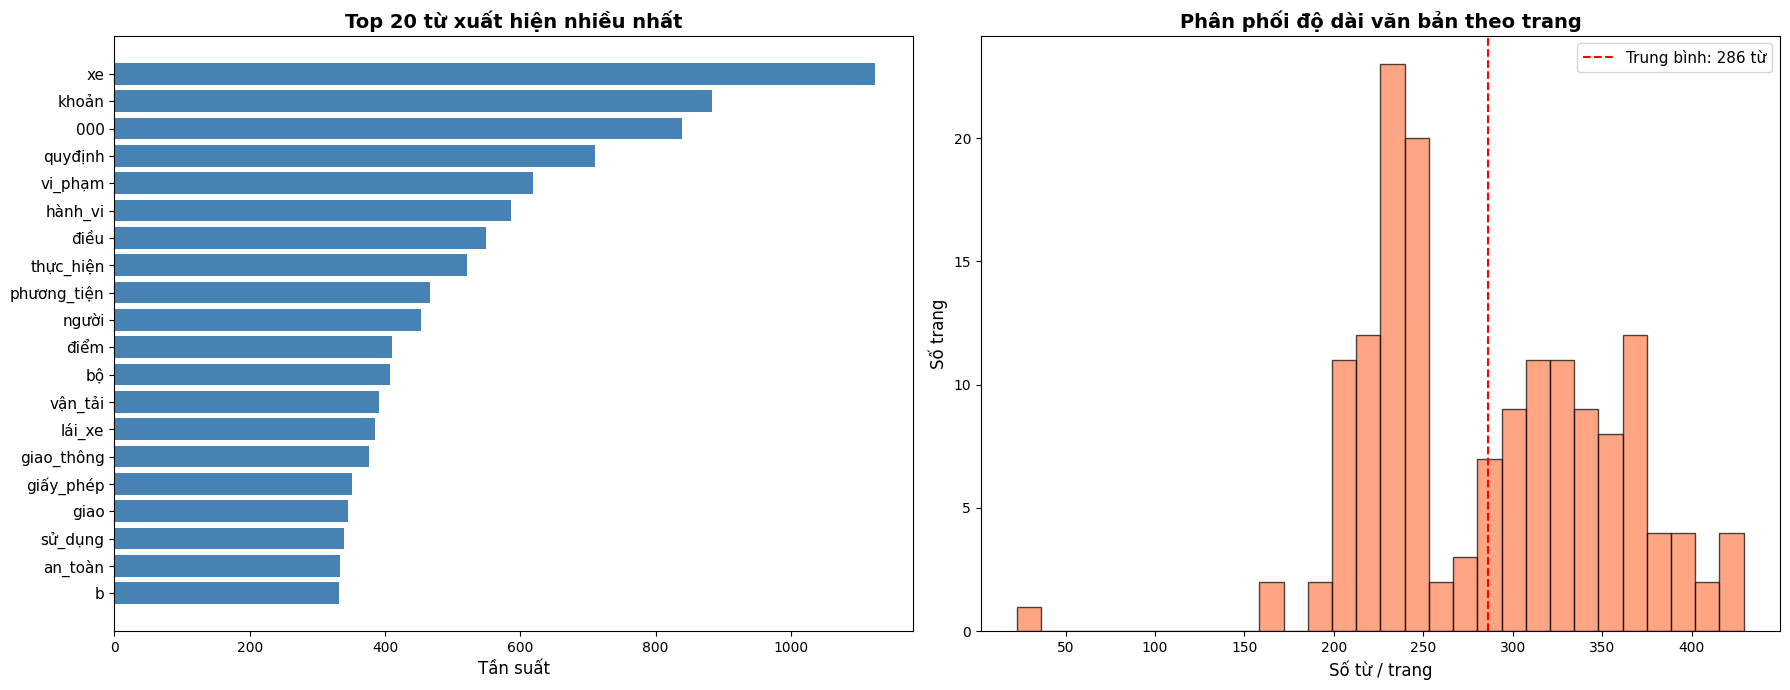

✓ Đã lưu biểu đồ tần suất từ


In [30]:
# Bước 7: Khám phá dữ liệu (Data Exploration)
print("=" * 50)
print("BƯỚC 7: KHÁM PHÁ DỮ LIỆU (DATA EXPLORATION)")
print("=" * 50)

# --- 7.1. Tần suất từ (Word Frequency) ---
all_tokens = []
for page in all_pages:
    all_tokens.extend(page["text_tokenized"].split())

word_freq = Counter(all_tokens)
top_30 = word_freq.most_common(30)

print("\n📊 TOP 30 TỪ XUẤT HIỆN NHIỀU NHẤT:")
print("-" * 40)
for i, (word, count) in enumerate(top_30, 1):
    print(f"  {i:2d}. {word:<25s} {count:>6,}")

# --- 7.2. Biểu đồ tần suất từ ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Biểu đồ cột - Top 20 từ
top_20 = word_freq.most_common(20)
words_list = [w for w, c in top_20]
counts_list = [c for w, c in top_20]

axes[0].barh(range(len(words_list)), counts_list, color='steelblue')
axes[0].set_yticks(range(len(words_list)))
axes[0].set_yticklabels(words_list, fontsize=11)
axes[0].invert_yaxis()
axes[0].set_xlabel('Tần suất', fontsize=12)
axes[0].set_title('Top 20 từ xuất hiện nhiều nhất', fontsize=14, fontweight='bold')

# Biểu đồ phân phối độ dài văn bản
page_lengths = [len(p["text_tokenized"].split()) for p in all_pages]
axes[1].hist(page_lengths, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Số từ / trang', fontsize=12)
axes[1].set_ylabel('Số trang', fontsize=12)
axes[1].set_title('Phân phối độ dài văn bản theo trang', fontsize=14, fontweight='bold')
axes[1].axvline(x=sum(page_lengths)/len(page_lengths), color='red', linestyle='--', 
                label=f'Trung bình: {sum(page_lengths)/len(page_lengths):.0f} từ')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "word_frequency_chart.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Đã lưu biểu đồ tần suất từ")

🌥️  Tạo Word Cloud...


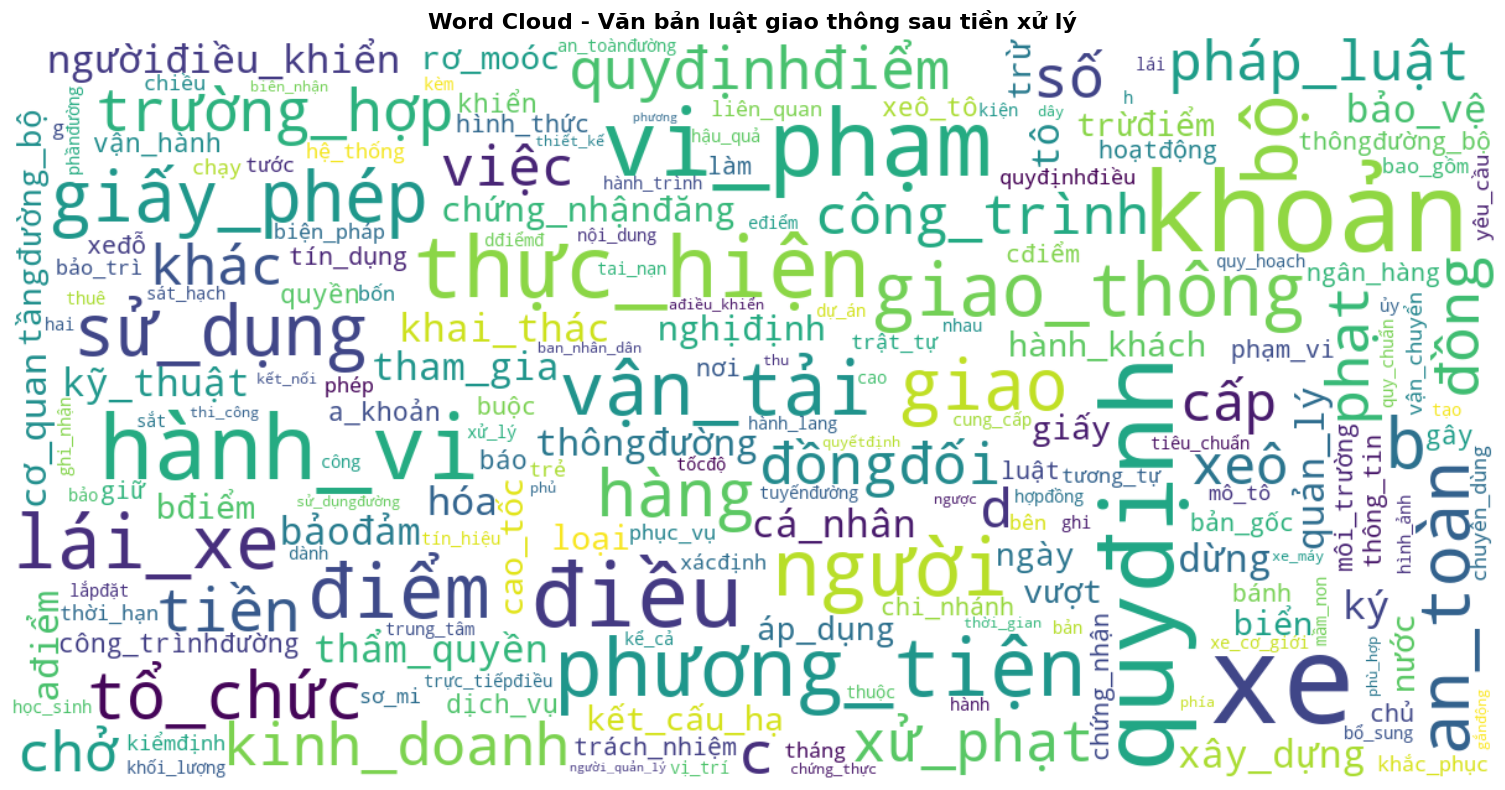

✓ Đã lưu Word Cloud

📊 THỐNG KÊ TỔNG HỢP SAU TIỀN XỬ LÝ
   Tổng số trang:         157
   Tổng số token:         44,960
   Số từ vựng duy nhất:   3,755
   Trung bình từ/trang:   286
   Trang dài nhất:        429 từ
   Trang ngắn nhất:       23 từ

   📄 Luật 35/2024:
      Số trang: 69
      Tổng token: 15,793

   📄 NĐ 168/2024:
      Số trang: 88
      Tổng token: 29,167


In [31]:
# --- 7.3. Word Cloud (Đám mây từ) ---
print("🌥️  Tạo Word Cloud...")

# Gộp tất cả token thành chuỗi
all_text = " ".join(page["text_tokenized"] for page in all_pages)

# Tạo Word Cloud
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200,
    colormap="viridis",
    collocations=False,
    font_path=None,  # Dùng font mặc định; nếu lỗi tiếng Việt, thay bằng đường dẫn font .ttf
    min_font_size=10,
    max_font_size=100,
)
wc.generate(all_text)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Văn bản luật giao thông sau tiền xử lý", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "wordcloud.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Đã lưu Word Cloud")

# --- 7.4. Thống kê tổng hợp ---
print("\n" + "=" * 50)
print("📊 THỐNG KÊ TỔNG HỢP SAU TIỀN XỬ LÝ")
print("=" * 50)
print(f"   Tổng số trang:         {len(all_pages):,}")
print(f"   Tổng số token:         {len(all_tokens):,}")
print(f"   Số từ vựng duy nhất:   {len(set(all_tokens)):,}")
print(f"   Trung bình từ/trang:   {len(all_tokens)/len(all_pages):.0f}")
print(f"   Trang dài nhất:        {max(page_lengths):,} từ")
print(f"   Trang ngắn nhất:       {min(page_lengths):,} từ")

# Thống kê theo nguồn
sources = set(p["source"] for p in all_pages)
for src in sources:
    src_pages = [p for p in all_pages if p["source"] == src]
    src_tokens = sum(len(p["text_tokenized"].split()) for p in src_pages)
    print(f"\n   📄 {src}:")
    print(f"      Số trang: {len(src_pages):,}")
    print(f"      Tổng token: {src_tokens:,}")

## Lưu dữ liệu đã tiền xử lý
Lưu kết quả tiền xử lý thành file JSON để sử dụng cho các bước tiếp theo (chunking, embedding, RAG).

In [32]:
# Lưu dữ liệu đã tiền xử lý
print("=" * 50)
print("LƯU DỮ LIỆU ĐÃ TIỀN XỬ LÝ")
print("=" * 50)

import builtins

# Chuẩn bị dữ liệu để lưu
output_data = {
    "metadata": {
        "total_pages": len(all_pages),
        "sources": list(set(p["source"] for p in all_pages)),
        "preprocessing_steps": [
            "1. Lowercasing (chuyển chữ thường)",
            "2. Remove Punctuation (xóa dấu chấm câu)",
            "3. Remove Stopwords (xóa từ dừng)",
            "4. Text Standardization (chuẩn hóa văn bản)",
            "5. Spelling Correction (chỉnh sửa chính tả)",
            "6. Tokenization (tách từ - underthesea)",
        ],
        "total_tokens": sum(len(p["text_tokenized"].split()) for p in all_pages),
        "unique_tokens": len(set(token for p in all_pages for token in p["text_tokenized"].split())),
    },
    "pages": []
}

for page in all_pages:
    output_data["pages"].append({
        "source": page["source"],
        "page": page["page"],
        "text_original": page["text"],
        "text_processed": page["text_processed"],
        "text_tokenized": page["text_tokenized"],
    })

# Lưu file JSON
output_path = PROCESSED_DIR / "preprocessed_data.json"
with builtins.open(output_path, "w", encoding="utf-8") as f:
    json.dump(output_data, f, ensure_ascii=False, indent=2)

file_size = output_path.stat().st_size / 1024
print(f"\n✅ Đã lưu: {output_path}")
print(f"   Kích thước: {file_size:.1f} KB")
print(f"   Số trang: {len(output_data['pages']):,}")
print(f"   Tổng token: {output_data['metadata']['total_tokens']:,}")
print(f"   Từ vựng duy nhất: {output_data['metadata']['unique_tokens']:,}")

# Lưu riêng từng nguồn
for src in output_data["metadata"]["sources"]:
    src_pages = [p for p in output_data["pages"] if p["source"] == src]
    src_name = src.replace(".json", "").replace(" ", "_")
    src_path = PROCESSED_DIR / f"preprocessed_{src_name}.json"
    with builtins.open(src_path, "w", encoding="utf-8") as f:
        json.dump({"pages": src_pages}, f, ensure_ascii=False, indent=2)
    print(f"   📄 Đã lưu: preprocessed_{src_name}.json ({len(src_pages)} trang)")

print("\n🎉 HOÀN TẤT TIỀN XỬ LÝ DỮ LIỆU!")

LƯU DỮ LIỆU ĐÃ TIỀN XỬ LÝ

✅ Đã lưu: C:\Users\ASUS-PRO\Desktop\Traffic_Law_Chatbot\data\processed\preprocessed_data.json
   Kích thước: 1398.0 KB
   Số trang: 157
   Tổng token: 44,960
   Từ vựng duy nhất: 3,755


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\ASUS-PRO\\Desktop\\Traffic_Law_Chatbot\\data\\processed\\preprocessed_Luật_35\\2024.json'